
# 📚 Book Selection Workflow V3 — Map-Reduce Discovery + Download Pipeline

Replaces the non-deterministic ReAct discovery loop with a **map-reduce pipeline**
using LangGraph's `Send` API, and adds an automated **book download phase**:

```
START
  → fetch_course (Neo4j)
  → discover_books
      └─ Discovery Sub-Graph (map-reduce):
           generate_queries (1 LLM call → 10-12 queries)
           → fan_out(search_and_extract ×N parallel):
               each worker: run 1 query × 2 tools → 1 small LLM extract
           → deduplicate_books (1 LLM call → merged unique list)
  → fan_out (Send per book)
    → score_book (ReAct research + structured scoring) × N parallel
  → select_top_books (pick top 5 by S_final)
  → fan_out_downloads (Send per top book)
    → download_book × 5 parallel
        └─ Download Sub-Graph (ReAct + deterministic):
             dl_search ⇄ dl_tools (DuckDuckGo, Tavily, Open Library)
             → extract_urls (structured output → candidate URLs)
             → attempt_download (HEAD→GET, validate PDF, save locally)
  → END
```

## Key Changes from V2
| Aspect | V2 (workflow.ipynb) | V3 (this notebook) |
|--------|--------------------|-----------|
| Discovery | ReAct loop (agent ⇄ tools, ≤6 rounds) | Map-Reduce: generate → fan_out(search+extract ×N) → dedup |
| LLM calls (discovery) | ~7-13 (variable) | **N+1** (1 query gen + N per-query extractions) |
| Per-LLM-call input size | Huge (all results combined) | **Small** (2 search results per call) |
| Search execution | Serial (1-2 per round) | **All at once** (parallel via Send) |
| Determinism | Non-deterministic | Fully deterministic |
| Download | ❌ None | ✅ ReAct search → extract URLs → download |

## Discovery Phase: Map-Reduce Pattern
```
                              ┌─ search_and_extract(q1) → [books] ─┐
generate_queries → fan_out ──►├─ search_and_extract(q2) → [books] ─┤──► deduplicate_books
                              ├─ search_and_extract(q3) → [books] ─┤
                              └─ …                       (×N)    ──┘
```
**Why map-reduce?** Instead of feeding ALL search results into one massive LLM call
(risking context overflow and poor extraction), each query's results are processed
by their own small, focused LLM call. Results are then merged and deduplicated
deterministically (fuzzy title match — no LLM needed for dedup).

## Download Phase Tools
| Tool | API Key | Best For |
|------|---------|----------|
| `duckduckgo_search` | None | `filetype:pdf` queries, broad web search |
| `tavily_search` | Required | Deep web search, PDF download pages |
| `open_library_search` | None | ISBNs, Internet Archive lending links |
| `download_file_from_url` | None | Validates & saves PDF/EPUB files locally |

## Workflow Parameter: `course_level`
Accepted values: `bachelor` (default), `master`, `phd`.
Used by the C_scope criterion to match book depth against the course's academic level.

## Scoring: $S_{final} = \sum_{j=1}^{6} w_j \cdot C_j$

| Criterion | $w_j$ | Rubric (1.0 → 0.1) |
|-----------|--------|---------------------|
| Topic Coverage ($C_{topic}$) | 0.30 | ≥90% → <40% course topics |
| Structural Alignment ($C_{struc}$) | 0.20 | Chapters↔syllabus 1:1 → no TOC |
| Scope & Depth ($C_{scope}$) | 0.15 | Perfect level match for `course_level` → wrong audience |
| Publisher Reputation ($C_{pub}$) | 0.15 | Elite → indie/unknown |
| Author Authority ($C_{auth}$) | 0.10 | Leading expert → unknown |
| Recency ($C_{time}$) | 0.10 | ≤3yr → >12yr |

**Optional**: $S_{prac} = (1 - w_{prac}) \cdot S_{base} + w_{prac} \cdot C_{prac}$


In [1]:
# ═══════════════════════════════════════════════════════════════
# Imports & Configuration
# ═══════════════════════════════════════════════════════════════
import asyncio
import json
import operator
import os
from collections import defaultdict
from datetime import date
from typing import Annotated, Any, TypedDict

from dotenv import load_dotenv

load_dotenv()

from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.types import Send
from pydantic import BaseModel, Field, SecretStr, field_validator, model_validator

from app.modules.curricularalignmentarchitect.tools import (
    TOOLS,
    TOOLS_BY_NAME,
    googlebooksqueryrun,
    tavily_search,
)

# ── Env helpers ─────────────────────────────────────────────────


def _env(*names: str, default: str | None = None) -> str | None:
    """Return the first non-empty env var from *names*, or *default*."""
    for n in names:
        v = os.getenv(n)
        if v:
            return v
    return default


MODEL = _env("LAB_TUTOR_LLM_MODEL", "LLM_MODEL", "XIAOCASE_MODEL", default="gpt-5.2")
API_BASE = _env(
    "LAB_TUTOR_LLM_BASE_URL",
    "LLM_BASE_URL",
    "XIAOCASE_API_BASE",
    default="https://api.xiaocaseai.com/v1",
)
API_KEY = _env(
    "LAB_TUTOR_LLM_API_KEY", "LLM_API_KEY", "XIAOCASE_API_KEY", "OPENAI_API_KEY"
)

if not API_KEY:
    raise ValueError(
        "No LLM API key found. Set LAB_TUTOR_LLM_API_KEY or XIAOCASE_API_KEY."
    )

# ── Valid course levels ─────────────────────────────────────────
VALID_COURSE_LEVELS = {"bachelor", "master", "phd"}
DEFAULT_COURSE_LEVEL = "bachelor"

# ── Dynamic date context ────────────────────────────────────────
_today = date.today()
_current_year = _today.year

print(f"✅ Config loaded | model={MODEL} | base_url={API_BASE} | year={_current_year}")

# ── Helper functions ────────────────────────────────────────────


def _course_summary(ctx: dict, course_level: str = DEFAULT_COURSE_LEVEL) -> str:
    """One-paragraph course overview for LLM prompts."""
    c = ctx.get("course", {})
    docs = ctx.get("documents", [])
    keywords = []
    for d in docs:
        keywords.extend(d.get("keywords", []))
    unique_kw = list(dict.fromkeys(keywords))[:40]
    return (
        f"Course: {c.get('title', '?')}\n"
        f"Academic Level: {course_level.upper()}\n"
        f"Description: {c.get('description', 'N/A')}\n"
        f"Keywords ({len(unique_kw)}): {', '.join(unique_kw)}"
    )


def _syllabus_sequence(ctx: dict) -> str:
    """Numbered lecture list with source_filename + keywords for structural alignment."""
    docs = ctx.get("documents", [])
    if not docs:
        return "(no documents)"
    lines = []
    for i, d in enumerate(docs, 1):
        title = d.get("title", "Untitled")
        kw = d.get("keywords", [])
        fn = d.get("source_filename", "")
        kw_str = ", ".join(str(k) for k in kw[:8])
        prefix = f"[{fn}] " if fn else ""
        lines.append(f"  {i:>2}. {prefix}{title}  →  {kw_str}")
    return "\n".join(lines)


def _exec_tools(ai_msg: AIMessage, tools_by_name: dict) -> list[ToolMessage]:
    """Execute tool calls from an AIMessage and return ToolMessages."""
    results = []
    for tc in getattr(ai_msg, "tool_calls", []):
        tool_name = tc.get("name", "")
        tool = tools_by_name.get(tool_name)
        tool_call_id = tc.get("id", tool_name)
        if tool is None:
            results.append(
                ToolMessage(
                    content=json.dumps(
                        {"ok": False, "error": f"Unknown tool: {tool_name}"}
                    ),
                    tool_call_id=tool_call_id,
                )
            )
            continue
        observation = tool.invoke(tc.get("args", {}))
        results.append(ToolMessage(content=observation, tool_call_id=tool_call_id))
    return results


print("✅ Helpers defined: _env, _course_summary, _syllabus_sequence, _exec_tools")

✅ Config loaded | model=deepseek-v3.2 | base_url=https://api.xiaocaseai.com/v1 | year=2026
✅ Helpers defined: _env, _course_summary, _syllabus_sequence, _exec_tools


In [2]:
# ═══════════════════════════════════════════════════════════════
# Offline Pretty-Print Tracer (no LangSmith needed)
# ═══════════════════════════════════════════════════════════════
import time as _time


class PrettyTracer:
    """Collects and pretty-prints LangGraph streaming events.
    Use with `workflow.astream(..., stream_mode="updates")`.
    """

    ICONS = {
        "fetch_course": "📦",
        "discover_books": "🔍",
        "score_book": "📊",
        "generate_queries": "🧠",
        "search_and_extract": "🔍",
        "deduplicate_books": "📚",
        "agent": "🤖",
        "tools": "🔧",
        "research": "🔬",
        "score": "⚖️",
        "select_top_books": "🏆",
        "download_book": "⬇️",
        "dl_search": "🔎",
        "dl_tools": "🔧",
        "extract_urls": "🔗",
        "attempt_download": "💾",
    }

    def __init__(self, verbose: bool = True):
        self.verbose = verbose
        self.t0 = _time.time()
        self.step_count = 0
        self.node_timings: dict[str, list[float]] = defaultdict(list)
        self._node_starts: dict[str, float] = {}
        self.tool_calls_log: list[dict] = []
        self.events_log: list[dict] = []

    def _elapsed(self) -> str:
        return f"{_time.time() - self.t0:.1f}s"

    def _bar(self, char="─", width=90) -> str:
        return char * width

    def _header(self, text: str, icon: str = "▶", width: int = 90) -> str:
        line = f"{icon} {text}"
        return f"\n{'═' * width}\n{line}\n{'═' * width}"

    def on_node_start(self, node_name: str, metadata: dict | None = None):
        self.step_count += 1
        self._node_starts[node_name] = _time.time()
        icon = self.ICONS.get(node_name, "▶")
        ts = self._elapsed()
        print(self._header(f"Step {self.step_count}: {node_name}", icon=icon))
        print(f"  ⏱  +{ts} elapsed")
        if metadata:
            for k, v in metadata.items():
                val = str(v)[:200]
                print(f"  📎 {k}: {val}")

    def on_node_end(self, node_name: str, output: dict):
        duration = _time.time() - self._node_starts.pop(node_name, _time.time())
        self.node_timings[node_name].append(duration)
        icon = self.ICONS.get(node_name, "✓")
        print(f"\n  {icon} {node_name} completed in {duration:.1f}s")
        print(f"  {self._bar('─', 70)}")

        if not output:
            print("  (no output)")
            return

        for key, value in output.items():
            self._print_state_delta(key, value)

        self.events_log.append(
            {
                "step": self.step_count,
                "node": node_name,
                "duration_s": round(duration, 2),
                "output_keys": list(output.keys()),
            }
        )

    def _print_state_delta(self, key: str, value):
        if key == "search_queries":
            if isinstance(value, list):
                print(f"  🧠 Generated {len(value)} search queries:")
                for i, q in enumerate(value, 1):
                    print(f"      {i:>2}. {q}")
        elif key == "search_results":
            if isinstance(value, list):
                total = sum(len(r.get("results", [])) for r in value)
                ok_count = sum(1 for r in value if r.get("ok", False))
                print(
                    f"  🔧 Executed {len(value)} searches ({ok_count} succeeded, "
                    f"{total} total results)"
                )
        elif key == "discovered_books":
            if isinstance(value, list):
                print(f"  📚 discovered_books: {len(value)} books")
                for i, b in enumerate(value[:10], 1):
                    title = b.get("title", "?")[:60]
                    authors = b.get("authors", "?")[:30]
                    year = b.get("year", "?")
                    print(f"      {i:>2}. {title} — {authors} ({year})")
                if len(value) > 10:
                    print(f"      … and {len(value) - 10} more")
        elif key == "raw_books":
            if isinstance(value, list):
                print(f"  🔍 raw_books: +{len(value)} extracted from map worker")
        elif key == "scored_books":
            if isinstance(value, list):
                for s in value:
                    title = s.get("book_title", "?")[:50]
                    sf = s.get("S_final", "?")
                    sp = s.get("S_final_with_prac", "?")
                    err = s.get("error")
                    if err:
                        print(f"  ❌ {title}: {err}")
                    else:
                        print(f"  ✅ {title}: S_final={sf:.3f}  S+prac={sp:.3f}")
        elif key == "final_scores":
            if isinstance(value, dict) and value:
                title = value.get("book_title", "?")[:50]
                sf = value.get("S_final", 0)
                print(f"  ⚖️  Scored: {title} → S_final={sf:.3f}")
                for crit in [
                    "C_topic",
                    "C_struc",
                    "C_scope",
                    "C_pub",
                    "C_auth",
                    "C_time",
                    "C_prac",
                ]:
                    sc = value.get(crit)
                    rat = value.get(f"{crit}_rationale", "")
                    if sc is not None:
                        print(f"      {crit}: {sc:.2f}  — {rat[:65]}")
        elif key == "course_context":
            if isinstance(value, dict):
                c = value.get("course", {})
                docs = value.get("documents", [])
                print(f"  📦 Course: {c.get('title', '?')} | {len(docs)} docs loaded")
        elif key == "top_books":
            if isinstance(value, list):
                print(f"  🏆 Selected top {len(value)} books for download")
                for i, b in enumerate(value, 1):
                    print(
                        f"      {i}. [{b.get('S_final', 0):.3f}] "
                        f"{b.get('book_title', '?')[:55]}"
                    )
        elif key == "download_results":
            if isinstance(value, list):
                for dr in value:
                    title = dr.get("book_title", "?")[:50]
                    status = dr.get("status", "?")
                    if status == "success":
                        print(f"  ✅ Downloaded: {title}")
                        print(f"      → {dr.get('file_path', '?')}")
                    elif status == "no_urls":
                        print(f"  ⚠️  No URLs: {title}")
                    else:
                        print(f"  ❌ Failed: {title} — {dr.get('error', '?')[:60]}")
        elif key == "download_result":
            if isinstance(value, dict) and value:
                title = value.get("book_title", "?")[:50]
                status = value.get("status", "?")
                if status == "success":
                    print(f"  💾 Downloaded: {title}")
                    print(f"      → {value.get('file_path', '?')}")
                else:
                    print(f"  ❌ Download {status}: {title}")
        elif key == "candidate_urls":
            if isinstance(value, list):
                print(f"  🔗 Found {len(value)} candidate URLs")
                for u in value[:3]:
                    print(
                        f"      [{u.get('confidence', 0):.1f}] "
                        f"{u.get('source_domain', '?')}: {u.get('url', '?')[:70]}"
                    )
        else:
            val_str = str(value)[:200]
            print(f"  📝 {key}: {val_str}")

    def summary(self):
        total = _time.time() - self.t0
        print(self._header("EXECUTION SUMMARY", icon="📊"))
        print(f"  Total time:  {total:.1f}s")
        print(f"  Total steps: {self.step_count}")

        print("\n  ⏱  Node Timings:")
        for node, times in sorted(self.node_timings.items()):
            avg = sum(times) / len(times)
            total_t = sum(times)
            print(
                f"      {node:<20} × {len(times):>3}  "
                f"avg={avg:.1f}s  total={total_t:.1f}s"
            )

        print(f"\n{'═' * 90}")


print("✅ PrettyTracer defined")

✅ PrettyTracer defined


In [3]:
# ═══════════════════════════════════════════════════════════════
# Course Context + Pydantic Models + Scoring Weights
# ═══════════════════════════════════════════════════════════════
from neo4j import GraphDatabase


def get_course_context(course_id: int) -> dict:
    """Fetch course metadata + uploaded document summaries from Neo4j.
    Includes source_filename for lecture sequencing."""
    uri = _env("LAB_TUTOR_NEO4J_URI", "NEO4J_URI")
    usr = _env("LAB_TUTOR_NEO4J_USERNAME", "NEO4J_USERNAME", default="neo4j")
    pwd = _env("LAB_TUTOR_NEO4J_PASSWORD", "NEO4J_PASSWORD")
    db = os.getenv("LAB_TUTOR_NEO4J_DATABASE", "neo4j")
    if not (uri and usr and pwd):
        raise ValueError("Neo4j not configured.")

    query = """
    MATCH (c:CLASS {id: $cid})
    OPTIONAL MATCH (d:TEACHER_UPLOADED_DOCUMENT) WHERE d.course_id = $cid
    WITH c, d ORDER BY d.source_filename ASC
    WITH c, collect(CASE WHEN d IS NULL THEN NULL ELSE {
      title: coalesce(d.topic, ""),
      keywords: coalesce(d.keywords, []),
      summary: coalesce(d.summary, ""),
      source_filename: coalesce(d.source_filename, "")
    } END) AS docs
    RETURN c.title AS t, c.description AS desc,
           [x IN docs WHERE x IS NOT NULL] AS docs
    """
    drv = GraphDatabase.driver(uri, auth=(usr, pwd))
    try:
        with drv.session(database=db) as s:
            r = s.run(query, {"cid": course_id}).single()
            if not r:
                raise ValueError(f"Course {course_id} not found.")
            return {
                "course": {
                    "id": course_id,
                    "title": r["t"] or "",
                    "description": r["desc"] or "",
                },
                "documents": [
                    {
                        "title": d["title"],
                        "keywords": [str(k) for k in d["keywords"] if k],
                        "summary": d["summary"],
                        "source_filename": d["source_filename"],
                    }
                    for d in r["docs"]
                ],
            }
    finally:
        drv.close()


course_context = get_course_context(course_id=1)
print(
    f"✅ Course: {course_context['course']['title']} "
    f"| {len(course_context['documents'])} docs"
)
print("\n📋 Syllabus Sequence:")
print(_syllabus_sequence(course_context))


# ── Pydantic Models ─────────────────────────────────────────────


class SearchQueryBatch(BaseModel):
    """LLM-generated batch of search queries for book discovery."""

    rationale: str = Field(
        ...,
        description="Brief explanation: what subject/discipline was identified "
        "and what query strategy was used.",
    )
    queries: list[str] = Field(
        ...,
        min_length=6,
        max_length=15,
        description="10-12 diverse, short (3-12 word) search queries. "
        "Each query will be executed on BOTH Google Books and Tavily.",
    )

    @field_validator("rationale", mode="before")
    @classmethod
    def coerce_rationale(cls, v):
        if isinstance(v, dict):
            return json.dumps(v, ensure_ascii=False)
        return str(v)


class DiscoveredBook(BaseModel):
    title: str
    authors: str = ""
    publisher: str = ""
    year: str = ""
    reason: str = Field("", description="Why this book is relevant")


class DiscoveredBookList(BaseModel):
    """Robust wrapper — accepts 'books', 'textbooks', 'items', or 'results' from LLMs."""

    books: list[DiscoveredBook]

    @model_validator(mode="before")
    @classmethod
    def normalize_field_names(cls, data: Any) -> Any:
        """DeepSeek (and other LLMs) sometimes return 'textbooks' instead of 'books'.
        This validator normalises the field name so Pydantic never rejects valid output."""
        if isinstance(data, dict) and "books" not in data:
            for alt in ("textbooks", "items", "results", "book_list"):
                if alt in data:
                    data["books"] = data.pop(alt)
                    break
            else:
                # If the dict has a single list value, use it
                lists = [v for v in data.values() if isinstance(v, list)]
                if len(lists) == 1:
                    data["books"] = lists[0]
        return data


class BookMeritScores(BaseModel):
    """LLM-evaluated 7-criteria scores, each in [0.0, 1.0]."""

    C_topic: float = Field(..., ge=0, le=1)
    C_topic_rationale: str
    C_struc: float = Field(..., ge=0, le=1)
    C_struc_rationale: str
    C_scope: float = Field(..., ge=0, le=1)
    C_scope_rationale: str
    C_pub: float = Field(..., ge=0, le=1)
    C_pub_rationale: str
    C_auth: float = Field(..., ge=0, le=1)
    C_auth_rationale: str
    C_time: float = Field(..., ge=0, le=1)
    C_time_rationale: str
    C_prac: float = Field(0, ge=0, le=1)
    C_prac_rationale: str = ""


# ── Weights (Σ = 1.0) ──────────────────────────────────────────

WEIGHTS = {
    "C_topic": 0.30,
    "C_struc": 0.20,
    "C_scope": 0.15,
    "C_pub": 0.15,
    "C_auth": 0.10,
    "C_time": 0.10,
}
W_PRAC = 0


def compute_finals(scores: dict) -> tuple[float, float]:
    """Return (S_final, S_final_with_practicality)."""
    print(f"\n✅ Models & weights defined | Σw = {sum(WEIGHTS.values()):.2f}")

    s_base = sum(WEIGHTS[k] * scores[k] for k in WEIGHTS)
    s_prac = (1 - W_PRAC) * s_base + W_PRAC * scores.get("C_prac", 0)
    return round(s_base, 4), round(s_prac, 4)

✅ Course: Big Data | 38 docs

📋 Syllabus Sequence:
   1. [4 types of NoSQL.docx] Four Types of NoSQL Databases  →  NoSQL, Key Value Pair Based, Column-based, Document-Oriented, Graph-Based, key-value pair, JSON, aggregation queries
   2. [BDA 4-1.docx] Data Storing System and Data Modeling in Big Data  →  Data storing system, Data modeling, Data collection, ETL (Extract Transform Load), Conceptual model, Logical model, Physical model, Unified data access interface
   3. [BDA 4-2.docx] Distributed File Systems in Big Data: Architecture and Operations of HDFS  →  big data computing system, data storing system, distributed file system, HDFS, Name node, Data node, data writing process, data reading process
   4. [BDA 4-3.docx] Introduction to NoSQL Databases  →  NoSQL, relational database (RDBMS), big data, distributed file system, scalability, data partition, shared-nothing architecture, asynchronous replication
   5. [BDA 4-4.docx] NoSQL Database Concepts: CAP Theorem and BASE Transactio

In [4]:
# ═══════════════════════════════════════════════════════════════
# Phase 1: Book Discovery — Map-Reduce Pipeline (LangGraph Send)
#   generate_queries → fan_out(search_and_extract ×N) → deduplicate_books
#
# KEY IMPROVEMENT: Instead of one giant LLM call with ALL search results,
# each query gets its own small LLM extraction call.
# This avoids context-window bloat and improves extraction quality.
# ═══════════════════════════════════════════════════════════════

from difflib import SequenceMatcher

QUERY_GENERATION_PROMPT = f"""\
You are an expert academic librarian. Your task is to generate a batch of search
queries that will be used to discover candidate textbooks for a university course.
Today's date: {_today.isoformat()}.

You will be given the course title, description, and a list of lecture topics
with keywords from the syllabus.

STRATEGY:
1. First, identify the academic SUBJECT / DISCIPLINE this course belongs to
   (e.g., a "Data Storage and Modeling" course → the subject is "Big Data"
   or "Database Systems"; a "Compilers" course → "Programming Languages").
2. Then generate 10-12 diverse queries covering:

   BROAD QUERIES (these are the most important!):
   - "<subject> textbook" — comprehensive books for the whole discipline
   - "<course title> textbook" — exact course-title match
   - "<subject> textbook {_current_year}" — recent/latest books
   - "<course title> syllabus reading list" — professor recommendations
   - "best <subject> textbooks {_current_year}" — curated recommendation lists
   - Well-known leading textbook authors in this field

   KEYWORD-COMBINATION QUERIES (2-3 of these):
   - Pick the 2-3 most distinctive keyword combinations from the syllabus
     and search for "<keyword1> <keyword2> textbook"

RULES:
- Each query MUST be SHORT: 3-12 words only.
- Queries must be DIVERSE — do not repeat the same terms across queries.
- Include the year "{_current_year}" in at least 2 queries so we find recent books.
- Focus on finding comprehensive textbooks that cover the WHOLE course.
- Include queries that would find classic/foundational textbooks in the field.
- Do NOT generate queries for individual sub-topics (e.g., "MapReduce textbook", "HDFS chapter").
  Instead, combine distinctive keywords: "Big Data MapReduce Spark textbook".
- Generate exactly 10-12 queries. No more, no less.
- Do not forget to provide the rationale explaining your query strategy and subject identification."""


PER_QUERY_EXTRACTION_PROMPT = """\
You are extracting textbooks from search results for a SINGLE search query.

RULES:
- Only include actual TEXTBOOKS — no articles, papers, blog posts, or web pages.
- For each book include: title, authors, publisher, year, and a brief reason
  explaining why it is relevant to the course.
- If no textbooks are found in these results, return an EMPTY list.
- Do NOT fabricate books that don't appear in the search results.
- If the same book appears in results from both tools, include it only ONCE.
- Typically expect 0-5 books per query.

OUTPUT FORMAT — return valid JSON with this exact structure:
{"books": [{"title": "...", "authors": "...", "publisher": "...", "year": "...", "reason": "..."}]}
The key MUST be "books" (not "textbooks" or anything else).
If no textbooks found, return: {"books": []}"""


class DiscoveryState(TypedDict, total=False):
    course_context: dict
    search_queries: list[str]
    query_rationale: str
    raw_books: Annotated[list[dict], operator.add]  # fan-in from map workers
    discovered_books: list[dict]  # final deduplicated output


# ── LLMs for discovery ──────────────────────────────────────────

query_gen_llm = ChatOpenAI(
    model=MODEL,
    base_url=API_BASE,
    api_key=SecretStr(API_KEY),
    temperature=0,
    timeout=60,
    max_completion_tokens=800,
).with_structured_output(SearchQueryBatch)

per_query_extract_llm = ChatOpenAI(
    model=MODEL,
    base_url=API_BASE,
    api_key=SecretStr(API_KEY),
    temperature=0,
    timeout=60,
    max_completion_tokens=1000,
).with_structured_output(DiscoveredBookList)


# ── Node 1: Generate Queries ────────────────────────────────────


async def generate_queries(state: DiscoveryState):
    """Single LLM call: course context → 10-12 search queries."""
    ctx = state.get("course_context", {})
    c = ctx.get("course", {})

    user_msg = (
        f"COURSE TITLE: {c.get('title', '')}\n"
        f"DESCRIPTION: {c.get('description', '')}\n\n"
        f"SYLLABUS (lectures with keywords):\n"
        f"{_syllabus_sequence(ctx)}\n\n"
        f"Generate 10-12 diverse search queries to discover textbooks for this course. "
        f"Include a brief rationale as a plain text string."
    )

    result: SearchQueryBatch = await query_gen_llm.ainvoke(
        [
            SystemMessage(content=QUERY_GENERATION_PROMPT),
            HumanMessage(content=user_msg),
        ]
    )

    print(f"\n🧠 Generated {len(result.queries)} queries:")
    for i, q in enumerate(result.queries, 1):
        print(f"   {i:>2}. {q}")
    print(f"\n   Rationale: {result.rationale[:200]}")

    return {
        "search_queries": result.queries,
        "query_rationale": result.rationale,
    }


# ── Fan-out: one Send per query (map phase) ─────────────────────


def fan_out_searches(state: DiscoveryState) -> list[Send]:
    """Map phase: dispatch each query to its own search_and_extract node."""
    queries = state.get("search_queries", [])
    ctx = state.get("course_context", {})
    print(
        f"\n🗺️  Fanning out {len(queries)} queries to parallel search_and_extract workers…"
    )
    return [
        Send("search_and_extract", {"query": q, "course_context": ctx}) for q in queries
    ]


# ── Node 2: Search + Extract per query (map worker) ─────────────


async def search_and_extract(state: dict):
    """Map worker: execute ONE query on both tools → small LLM extract.

    Each worker:
    1. Runs the query on Google Books + Tavily in parallel
    2. Feeds ONLY those 2 results to the LLM for extraction
    3. Returns extracted books → merged into parent state via operator.add

    This keeps each LLM call small and focused (2 search results instead of 20+).
    """
    query = state["query"]
    ctx = state.get("course_context", {})

    # ── Run both search tools concurrently ──
    async def _search(tool_fn, tool_name: str) -> dict:
        try:
            raw = await asyncio.to_thread(tool_fn.invoke, {"query": query})
            data = json.loads(raw) if isinstance(raw, str) else raw
            return {
                "tool": tool_name,
                "ok": data.get("ok", True),
                "results": data.get("results", []),
            }
        except Exception as e:
            return {"tool": tool_name, "ok": False, "results": [], "error": str(e)}

    gb_result, tv_result = await asyncio.gather(
        _search(googlebooksqueryrun, "googlebooksqueryrun"),
        _search(tavily_search, "tavily_search"),
    )

    ok_results = [r for r in [gb_result, tv_result] if r["ok"] and r["results"]]

    if not ok_results:
        print(f'   ⚠️  No results for query: "{query[:50]}"')
        return {"raw_books": []}

    # ── Small, focused LLM call: extract books from this query only ──
    parts = []
    for sr in ok_results:
        items_text = json.dumps(sr["results"], ensure_ascii=False)[:3000]
        parts.append(f"[{sr['tool']}]\n{items_text}")

    c = ctx.get("course", {})
    try:
        result: DiscoveredBookList = await per_query_extract_llm.ainvoke(
            [
                SystemMessage(content=PER_QUERY_EXTRACTION_PROMPT),
                HumanMessage(
                    content=(
                        f"COURSE: {c.get('title', '')}\n"
                        f'SEARCH QUERY: "{query}"\n\n'
                        f"SEARCH RESULTS:\n\n" + "\n---\n".join(parts)
                    )
                ),
            ]
        )
        books = [b.model_dump() for b in result.books]
    except Exception as e:
        print(f'   ❌ Extraction failed for query "{query[:40]}": {e}')
        books = []

    if books:
        print(
            f'   📗 "{query[:40]}" → {len(books)} book(s): '
            f"{', '.join(b['title'][:30] for b in books[:3])}"
        )

    return {"raw_books": books}


# ── Deterministic dedup helpers ─────────────────────────────────

import re as _re


def _normalize_title(title: str) -> str:
    """Lowercase, strip edition/subtitle noise, collapse whitespace."""
    t = title.lower().strip()
    # Remove common edition suffixes: "3rd edition", "(2nd ed.)", etc.
    t = _re.sub(r"\(?\d+\w{0,2}\s*(edition|ed\.?)\)?", "", t)
    # Remove punctuation except spaces
    t = _re.sub(r"[^\w\s]", " ", t)
    # Collapse whitespace
    t = _re.sub(r"\s+", " ", t).strip()
    return t


def _titles_match(a: str, b: str, threshold: float = 0.82) -> bool:
    """Fuzzy title match using SequenceMatcher."""
    na, nb = _normalize_title(a), _normalize_title(b)
    if na == nb:
        return True
    return SequenceMatcher(None, na, nb).ratio() >= threshold


def _pick_best_entry(entries: list[dict]) -> dict:
    """Among duplicate entries, keep the one with the most complete metadata
    and the latest year."""

    def _completeness(e: dict) -> tuple:
        filled = sum(
            1 for k in ("title", "authors", "publisher", "year", "reason") if e.get(k)
        )
        # Prefer latest year (treat non-numeric as 0)
        try:
            yr = int(e.get("year", "0"))
        except (ValueError, TypeError):
            yr = 0
        # Prefer longer reason (more informative)
        reason_len = len(e.get("reason", ""))
        return (filled, yr, reason_len)

    return max(entries, key=_completeness)


# ── Node 3: Deduplicate Books (deterministic — no LLM) ──────────


def deduplicate_books(state: DiscoveryState):
    """Reduce phase: deterministic fuzzy-match dedup on titles.

    No LLM call — just normalise titles, group duplicates, and keep
    the entry with the best metadata for each unique book.
    If there are no duplicates, all books pass through unchanged.
    """
    raw = state.get("raw_books", [])

    if not raw:
        print("   ⚠️  No books found across all searches!")
        return {"discovered_books": []}

    # Group duplicates by fuzzy title match
    groups: list[list[dict]] = []
    for book in raw:
        title = book.get("title", "")
        matched = False
        for group in groups:
            if _titles_match(title, group[0].get("title", "")):
                group.append(book)
                matched = True
                break
        if not matched:
            groups.append([book])

    # Pick best entry per group
    unique = [_pick_best_entry(g) for g in groups]

    dup_count = len(raw) - len(unique)
    if dup_count > 0:
        print(
            f"\n📚 Deduplicated: {len(raw)} raw → {len(unique)} unique "
            f"({dup_count} duplicates removed)"
        )
    else:
        print(f"\n📚 No duplicates found — all {len(unique)} books are unique")

    for i, b in enumerate(unique, 1):
        group_size = len(groups[i - 1])
        dup_marker = f" (×{group_size})" if group_size > 1 else ""
        print(
            f"      {i:>2}. {b['title'][:60]} — {b.get('authors', '?')[:30]} "
            f"({b.get('year', '?')}){dup_marker}"
        )

    return {"discovered_books": unique}


# ── Compile Discovery Sub-Graph (map-reduce via Send) ───────────

_dg = StateGraph(DiscoveryState)
_dg.add_node("generate_queries", generate_queries)
_dg.add_node("search_and_extract", search_and_extract)
_dg.add_node("deduplicate_books", deduplicate_books)

_dg.add_edge(START, "generate_queries")
_dg.add_conditional_edges("generate_queries", fan_out_searches)
_dg.add_edge("search_and_extract", "deduplicate_books")
_dg.add_edge("deduplicate_books", END)

discovery_graph = _dg.compile()

print("\n✅ Discovery sub-graph compiled (map-reduce):")
print("   generate_queries → fan_out(search_and_extract ×N) → deduplicate_books → END")
print("   Dedup is deterministic (fuzzy title match, no LLM call)")


✅ Discovery sub-graph compiled (map-reduce):
   generate_queries → fan_out(search_and_extract ×N) → deduplicate_books → END
   Dedup is deterministic (fuzzy title match, no LLM call)


In [5]:
# ═══════════════════════════════════════════════════════════════
# Phase 2: Per-Book Scoring Agent (Research → Tools → Score)
# ═══════════════════════════════════════════════════════════════

MAX_RESEARCH_ROUNDS = 5

RESEARCH_PROMPT = """\
You are a textbook research agent. Your job is to gather THOROUGH evidence
about a SINGLE book so it can be scored on 7 criteria. You MUST search
until you have solid evidence — do NOT guess or stop early.

CRITERIA YOU NEED EVIDENCE FOR:
1. C_topic – What topics/chapters does the book actually cover?
2. C_struc – What is the book's chapter-by-chapter structure / TOC?
3. C_scope – What academic level is it (intro, intermediate, graduate)?
4. C_pub   – Who published it? (MIT Press, O'Reilly, Springer = elite)
5. C_auth  – Is the author a known expert? What are their credentials?
6. C_time  – What year was this specific edition published?
7. C_prac  – Does it have labs, code examples, exercises, projects?

MANDATORY SEARCH STRATEGY (do ALL of these):
1. googlebooksqueryrun \"{title} {author}\" → publisher, year, description, categories.
   If year is known, add it: googlebooksqueryrun \"{title} {year} edition\".
2. tavily_search \"{title} {year} table of contents chapters\" → find the actual TOC.
   THIS IS CRITICAL for C_topic and C_struc — you need to know WHAT the book covers.
3. tavily_search \"{title} {year} review topics covered\" → what readers say it covers.
4. If author credentials are unclear: tavily_search \"{author} professor university\".
5. If publisher is unclear from step 1: tavily_search \"{title} publisher edition\".

RULES:
- ALWAYS include the publication year in your search queries when known,
  because different editions cover different topics.
- You MUST do at least 3 searches. Do up to 5 if evidence is thin.
- The most important evidence is the TABLE OF CONTENTS — prioritize finding it.
- Do NOT stop after 1 search. The scoring agent needs rich evidence.
- If googlebooksqueryrun gave a good description, you still need the TOC from the web."""

# NOTE: {course_level} placeholder is filled at scoring time in score_node().
SCORING_PROMPT_TEMPLATE = """\
Score this book on 7 criteria (0.0–1.0). Use the research evidence AND your knowledge.

You will be given:
- The COURSE SYLLABUS SEQUENCE: numbered lectures in teaching order with keywords.
- The COURSE ACADEMIC LEVEL (bachelor / master / phd).
- The BOOK metadata and RESEARCH EVIDENCE (TOC, reviews, descriptions).

RUBRICS:

C_topic (w=0.30) — TOPIC COVERAGE:
  Compare the book's known chapters/topics against the course keywords.
  1.0: Book covers ≥90% of course topics/keywords
  0.7: Book covers 70–90% of course topics
  0.4: Book covers 40–70% of course topics
  0.1: Book covers <40% of course topics
  → In your rationale, LIST which course topics are covered and which are missing.

C_struc (w=0.20) — STRUCTURAL ALIGNMENT:
  Compare the book's chapter ORDER against the SYLLABUS SEQUENCE below.
  Can a teacher assign chapters week-by-week following the syllabus order?
  1.0: Chapters map nearly 1:1 to syllabus lectures in the SAME order
  0.7: Most chapters align but some reordering or skipping needed
  0.4: Selective chapters useful but heavy reordering required
  0.1: No meaningful structural correspondence or no TOC found
  → In your rationale, describe how chapters map to the lecture sequence.

C_scope (w=0.15) — SCOPE & DEPTH:
  The course academic level is: {course_level}

  Level-matching guide:
    Bachelor → introductory/intermediate textbooks, broad coverage, worked examples
    Master   → advanced/graduate texts, assumes prerequisites, deeper theory
    PhD      → research monographs, specialized topics, cutting-edge references

  1.0: Book explicitly targets the {course_level} level
       (e.g., stated audience matches, prerequisite expectations align)
  0.7: One level off — e.g., an advanced undergrad book for a master course,
       or a gentle graduate text for a bachelor course
  0.4: Two levels off — e.g., an introductory textbook for a PhD seminar,
       or a research monograph for a bachelor course
  0.1: Completely wrong audience — e.g., popular science for a graduate course,
       or a children's reference for any university level

  → In your rationale, state what level the book targets and how it compares
    to the {course_level} level of this course.

C_pub (w=0.15) — PUBLISHER REPUTATION:
  1.0: Elite (MIT Press, Oxford UP, Cambridge UP, O'Reilly, Wiley, Springer, ACM)
  0.8: Standard (Pearson, McGraw-Hill, Cengage, Addison-Wesley, Morgan Kaufmann)
  0.5: Indie / self-published / unknown

C_auth (w=0.10) — AUTHOR AUTHORITY:
  1.0: Leading expert, high h-index, top university
  0.7: Established academic
  0.4: Known practitioner
  0.1: Unknown

C_time (w=0.10) — RECENCY:
  1.0: ≤3 years old | 0.8: 4–7 yr | 0.5: 8–12 yr | 0.2: >12 yr

C_prac (w=0.0 optional) — PRACTICALITY:
  1.0: Extensive labs/code/exercises
  0.7: Good examples & problems
  0.4: Some exercises
  0.1: Theory only, no practice

RULES:
- Each rationale ≤2 sentences with specific evidence.
- Be calibrated: 1.0 = genuinely exceptional only.
- For C_topic: you MUST reference specific course keywords that match/miss.
- For C_struc: you MUST reference the lecture sequence numbers.
- For C_scope: you MUST compare the book's target audience against {course_level}."""


class ScoringState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    tool_rounds: int
    book: dict
    course_context: dict
    course_level: str
    final_scores: dict


research_llm = ChatOpenAI(
    model=MODEL,
    base_url=API_BASE,
    api_key=SecretStr(API_KEY),
    temperature=0,
    timeout=120,
    max_completion_tokens=600,
).bind_tools(TOOLS)

scoring_llm = ChatOpenAI(
    model=MODEL,
    base_url=API_BASE,
    api_key=SecretStr(API_KEY),
    temperature=0,
    timeout=90,
    max_completion_tokens=2000,
).with_structured_output(BookMeritScores)


def res_agent(state: ScoringState):
    return {
        "messages": [
            research_llm.invoke(
                [SystemMessage(content=RESEARCH_PROMPT), *state.get("messages", [])]
            )
        ]
    }


def res_tools(state: ScoringState):
    rounds = state.get("tool_rounds", 0) + 1
    if rounds > MAX_RESEARCH_ROUNDS:
        return {
            "messages": [AIMessage(content="Max research rounds reached.")],
            "tool_rounds": rounds,
        }
    return {
        "messages": _exec_tools(state["messages"][-1], TOOLS_BY_NAME),
        "tool_rounds": rounds,
    }


async def score_node(state: ScoringState):
    """Collect research evidence and produce structured BookMeritScores."""
    book = state["book"]
    ctx = state["course_context"]
    course_level = state.get("course_level", DEFAULT_COURSE_LEVEL)

    # Fill the course_level placeholder in the scoring prompt
    scoring_prompt = SCORING_PROMPT_TEMPLATE.format(course_level=course_level)

    evidence: list[str] = []
    for m in state.get("messages", []):
        if isinstance(m, ToolMessage):
            evidence.append(m.content[:800])
        elif (
            isinstance(m, AIMessage)
            and m.content
            and not getattr(m, "tool_calls", None)
        ):
            evidence.append(m.content[:500])

    syllabus = _syllabus_sequence(ctx)

    user_prompt = (
        f"COURSE:\n{_course_summary(ctx, course_level=course_level)}\n\n"
        f"═══ SYLLABUS SEQUENCE (lectures in teaching order) ═══\n"
        f"{syllabus}\n"
        f"═══════════════════════════════════════════════════════\n\n"
        f"BOOK: {book.get('title', '')}\n"
        f"Authors: {book.get('authors', '')}\n"
        f"Publisher: {book.get('publisher', '')}\n"
        f"Year: {book.get('year', '')}\n"
        f"Reason: {book.get('reason', '')}\n\n"
        f"RESEARCH EVIDENCE:\n"
        + "\n---\n".join(evidence[-10:])
        + "\n\nScore this book on ALL 7 criteria. "
        f"For C_topic, compare against the course keywords above. "
        f"For C_struc, compare the book's TOC against the SYLLABUS SEQUENCE above. "
        f"For C_scope, compare against the course level: {course_level}."
    )

    scores: BookMeritScores = await scoring_llm.ainvoke(
        [
            SystemMessage(content=scoring_prompt),
            HumanMessage(content=user_prompt),
        ]
    )

    result = scores.model_dump()
    sf, sp = compute_finals(result)
    result["S_final"] = sf
    result["S_final_with_prac"] = sp
    result["book_title"] = book.get("title", "")
    result["book_authors"] = book.get("authors", "")

    return {"final_scores": result}


def res_route(state: ScoringState) -> str:
    if state.get("tool_rounds", 0) >= MAX_RESEARCH_ROUNDS:
        return "score"
    last = (state.get("messages") or [None])[-1]
    return "tools" if last and getattr(last, "tool_calls", None) else "score"


_sb = StateGraph(ScoringState)
_sb.add_node("research", res_agent)
_sb.add_node("tools", res_tools)
_sb.add_node("score", score_node)
_sb.add_edge(START, "research")
_sb.add_conditional_edges("research", res_route, {"tools": "tools", "score": "score"})
_sb.add_edge("tools", "research")
_sb.add_edge("score", END)
scoring_graph = _sb.compile()

print(
    "✅ Scoring sub-graph compiled (research ⇄ tools → score → END) "
    f"| max_rounds={MAX_RESEARCH_ROUNDS}"
)

✅ Scoring sub-graph compiled (research ⇄ tools → score → END) | max_rounds=5


In [6]:
# ═══════════════════════════════════════════════════════════════
# Phase 3: Per-Book Download Agent (Search → Extract URLs → Download)
# ═══════════════════════════════════════════════════════════════

from app.modules.curricularalignmentarchitect.tools import (
    DOWNLOAD_SEARCH_TOOLS,
    DOWNLOAD_SEARCH_TOOLS_BY_NAME,
    download_file_from_url,
)

MAX_DOWNLOAD_SEARCH_ROUNDS = 4
MAX_DOWNLOAD_ATTEMPTS = 2
TOP_N_DOWNLOAD = 5

DOWNLOAD_SEARCH_PROMPT = """\
You are a book download agent. Your ONLY job is to find direct download URLs
for a specific book (PDF, EPUB, or DJVU format).

You will be given a book title, author, year, and publisher.
You have 3 search tools: duckduckgo_search, tavily_search, open_library_search.

MANDATORY SEARCH STRATEGY (do ALL of these):
1. duckduckgo_search "{title} {author} filetype:pdf"
   → This is your BEST tool for finding direct PDF links.

2. duckduckgo_search "{title} {author} pdf download free"
   → Broader search for download pages.

3. open_library_search "{title} {author}"
   → Check Open Library / Internet Archive for lending or free versions.
   → If the result includes an "IA:" link, that's a strong candidate.

4. tavily_search "{title} {year} pdf download"
   → Supplement with web search for the specific edition.

5. (Optional) If previous searches returned no PDF links:
   duckduckgo_search "{title} {author} free ebook"
   duckduckgo_search "{title} open access pdf"

IMPORTANT RULES:
- You MUST do at least 3 different searches before giving up.
- Focus on finding DIRECT download links (URLs ending in .pdf, .epub, .djvu).
- Archive.org links are valuable — they often have "download" pages.
- University repository links are excellent (e.g., .edu domains with /bitstream/).
- Do NOT fabricate URLs. Only report URLs that actually appeared in search results.
- After searching, summarize ALL candidate URLs you found with their sources.
- Prefer URLs that look like direct file links over generic book info pages."""


class CandidateURL(BaseModel):
    """A candidate download URL found by the search agent."""

    url: str = Field(..., description="Direct download URL or download page URL")
    confidence: float = Field(
        0.5,
        ge=0.0,
        le=1.0,
        description="Confidence this is a real download link (1.0=direct PDF link)",
    )


class CandidateURLList(BaseModel):
    """Extracted candidate URLs from search results."""

    urls: list[CandidateURL] = Field(default_factory=list)


class DownloadState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    tool_rounds: int
    book: dict  # {title, authors, year, publisher, S_final, ...}
    candidate_urls: list[dict]
    download_result: dict


# ── LLMs for download ──────────────────────────────────────────

dl_search_llm = ChatOpenAI(
    model=MODEL,
    base_url=API_BASE,
    api_key=SecretStr(API_KEY),
    temperature=0,
    timeout=120,
    max_completion_tokens=600,
).bind_tools(DOWNLOAD_SEARCH_TOOLS)

dl_extract_llm = ChatOpenAI(
    model=MODEL,
    base_url=API_BASE,
    api_key=SecretStr(API_KEY),
    temperature=0,
    timeout=60,
    max_completion_tokens=1500,
).with_structured_output(CandidateURLList)


# ── Node 1: Search Agent (ReAct loop for URL discovery) ────────


def dl_search_agent(state: DownloadState):
    """LLM agent that searches for book download links."""
    return {
        "messages": [
            dl_search_llm.invoke(
                [
                    SystemMessage(content=DOWNLOAD_SEARCH_PROMPT),
                    *state.get("messages", []),
                ]
            )
        ]
    }


def dl_search_tools(state: DownloadState):
    """Execute tool calls from the search agent."""
    rounds = state.get("tool_rounds", 0) + 1
    if rounds > MAX_DOWNLOAD_SEARCH_ROUNDS:
        return {
            "messages": [
                AIMessage(
                    content="Max download search rounds reached. "
                    "Proceeding to URL extraction."
                )
            ],
            "tool_rounds": rounds,
        }
    return {
        "messages": _exec_tools(state["messages"][-1], DOWNLOAD_SEARCH_TOOLS_BY_NAME),
        "tool_rounds": rounds,
    }


def dl_search_route(state: DownloadState) -> str:
    """Route: continue searching or move to extraction."""
    if state.get("tool_rounds", 0) >= MAX_DOWNLOAD_SEARCH_ROUNDS:
        return "extract_urls"
    last = (state.get("messages") or [None])[-1]
    return "dl_tools" if last and getattr(last, "tool_calls", None) else "extract_urls"


# ── Node 2: Extract candidate URLs (structured output) ─────────


async def dl_extract_urls(state: DownloadState):
    """LLM extracts candidate download URLs from all search evidence."""
    book = state["book"]

    # Collect all tool results and AI summaries
    evidence: list[str] = []
    for m in state.get("messages", []):
        if isinstance(m, ToolMessage):
            evidence.append(m.content[:1200])
        elif (
            isinstance(m, AIMessage)
            and m.content
            and not getattr(m, "tool_calls", None)
        ):
            evidence.append(m.content[:600])

    user_prompt = (
        f"Extract ALL candidate download URLs from the search results below.\n\n"
        f"BOOK: {book.get('title', '')} by {book.get('authors', '')} "
        f"({book.get('year', '')})\n"
        f"Publisher: {book.get('publisher', '')}\n\n"
        f"SEARCH EVIDENCE:\n"
        + "\n---\n".join(evidence[-12:])
        + "\n\nExtract every URL that could be a direct download link or a page "
        "where the book can be downloaded. Rate each URL's confidence. "
        "If you found NO usable URLs, return an empty list."
    )

    result: CandidateURLList = await dl_extract_llm.ainvoke(
        [
            SystemMessage(
                content=(
                    "Extract candidate download URLs from the search evidence. "
                    "Include ONLY URLs that actually appeared in the search results. "
                    "Rate confidence: 1.0 = URL ends in .pdf/.epub (direct link), "
                    "0.8 = download page on archive.org or similar, "
                    "0.5 = book page that might have a download option, "
                    "0.2 = tangential reference."
                )
            ),
            HumanMessage(content=user_prompt),
        ]
    )

    urls = [u.model_dump() for u in result.urls]
    # Sort by confidence descending
    urls.sort(key=lambda u: u.get("confidence", 0), reverse=True)

    print(
        f'\n  📋 Found {len(urls)} candidate URLs for "{book.get("title", "?")[:50]}":'
    )
    for i, u in enumerate(urls[:5], 1):
        print(f"      {i}. [{u.get('confidence', 0):.1f}] {u.get('url', '?')[:80]}")

    return {"candidate_urls": urls}


# ── Node 3: Attempt Download (deterministic, no LLM) ──────────


async def dl_attempt_download(state: DownloadState):
    """Try downloading from top candidate URLs (max 2 attempts).
    If both fail, record the URLs so the user can download manually."""
    book = state["book"]
    urls = state.get("candidate_urls", [])
    title = book.get("title", "unknown")

    # Build a sanitized filename from the book title
    import re as _re

    safe_fn = _re.sub(r"[^\w\s-]", "", title.strip())
    safe_fn = _re.sub(r"\s+", "_", safe_fn)[:80] or "book"

    if not urls:
        print(f'  ❌ No candidate URLs for "{title[:50]}"')
        return {
            "download_result": {
                "book_title": title,
                "status": "no_urls",
                "error": "No candidate download URLs found.",
            }
        }

    tried_urls: list[str] = []
    for i, candidate in enumerate(urls[:MAX_DOWNLOAD_ATTEMPTS]):
        url = candidate.get("url", "")
        conf = candidate.get("confidence", 0)

        if not url or not url.startswith("http"):
            continue

        tried_urls.append(url)
        print(
            f"  ⬇️  Attempt {i + 1}/{MAX_DOWNLOAD_ATTEMPTS}: "
            f"[{conf:.1f}] → {url[:70]}..."
        )

        try:
            raw_result = await asyncio.to_thread(
                download_file_from_url.invoke,
                {"url": url, "filename": safe_fn},
            )
            result_data = (
                json.loads(raw_result) if isinstance(raw_result, str) else raw_result
            )

            if result_data.get("ok"):
                results = result_data.get("results", [])
                dl_info = results[0] if results else {}
                print(f"  ✅ Downloaded! {dl_info.get('snippet', '')[:80]}")
                return {
                    "download_result": {
                        "book_title": title,
                        "book_authors": book.get("authors", ""),
                        "status": "success",
                        "file_path": dl_info.get("url", ""),  # local path
                        "file_info": dl_info.get("snippet", ""),
                        "source_url": url,
                    }
                }
            else:
                err = result_data.get("error", "Unknown error")
                print(f"      ⚠️  Failed: {err[:60]}")
        except Exception as e:
            print(f"      ⚠️  Error: {str(e)[:60]}")

    # All attempts failed — report URLs for manual download
    remaining_urls = [
        u.get("url", "") for u in urls if u.get("url", "") not in tried_urls
    ]
    print(
        f'  ❌ Download failed for "{title[:50]}" after {len(tried_urls)} attempt(s).'
    )
    if remaining_urls:
        print("  📝 Additional URLs for manual download:")
        for u in remaining_urls[:5]:
            print(f"      → {u}")

    return {
        "download_result": {
            "book_title": title,
            "status": "failed",
            "error": f"Tried {len(tried_urls)} URL(s), all failed. See manual_urls for manual download.",
            "tried_urls": tried_urls,
            "manual_urls": remaining_urls[:5],
        }
    }


# ── Compile Download Sub-Graph ─────────────────────────────────

_dlg = StateGraph(DownloadState)
_dlg.add_node("dl_search", dl_search_agent)
_dlg.add_node("dl_tools", dl_search_tools)
_dlg.add_node("extract_urls", dl_extract_urls)
_dlg.add_node("attempt_download", dl_attempt_download)

_dlg.add_edge(START, "dl_search")
_dlg.add_conditional_edges(
    "dl_search",
    dl_search_route,
    {"dl_tools": "dl_tools", "extract_urls": "extract_urls"},
)
_dlg.add_edge("dl_tools", "dl_search")
_dlg.add_edge("extract_urls", "attempt_download")
_dlg.add_edge("attempt_download", END)

download_graph = _dlg.compile()

print(
    "✅ Download sub-graph compiled: "
    "dl_search ⇄ dl_tools → extract_urls → attempt_download → END"
)
print(
    f"   max_search_rounds={MAX_DOWNLOAD_SEARCH_ROUNDS} | "
    f"max_download_attempts={MAX_DOWNLOAD_ATTEMPTS} | top_n={TOP_N_DOWNLOAD}"
)
print(f"   Search tools: {[t.name for t in DOWNLOAD_SEARCH_TOOLS]}")

✅ Download sub-graph compiled: dl_search ⇄ dl_tools → extract_urls → attempt_download → END
   max_search_rounds=4 | max_download_attempts=2 | top_n=5
   Search tools: ['duckduckgo_search', 'tavily_search', 'open_library_search']


In [7]:
# ═══════════════════════════════════════════════════════════════
# Main Orchestrator: fetch_course → discover → fan_out(score)
#                    → select_top → fan_out(download) → END
# ═══════════════════════════════════════════════════════════════


class WorkflowState(TypedDict, total=False):
    course_context: dict
    course_level: str  # "bachelor" | "master" | "phd" (default: "bachelor")
    discovered_books: list[dict]
    scored_books: Annotated[list[dict], operator.add]
    top_books: list[dict]
    download_results: Annotated[list[dict], operator.add]


def fetch_course(state: WorkflowState):
    """Load course context from Neo4j. Propagate course_level from input state."""
    ctx = get_course_context(course_id=1)
    level = state.get("course_level", DEFAULT_COURSE_LEVEL)
    if level not in VALID_COURSE_LEVELS:
        print(
            f"⚠️  Unknown course_level '{level}', defaulting to '{DEFAULT_COURSE_LEVEL}'"
        )
        level = DEFAULT_COURSE_LEVEL
    print(f"  🎓 Course level: {level}")
    return {"course_context": ctx, "course_level": level}


async def discover_books(state: WorkflowState):
    """Run the structured discovery pipeline (generate → search → extract)."""
    ctx = state["course_context"]
    result = await discovery_graph.ainvoke(
        {
            "course_context": ctx,
        }
    )
    return {"discovered_books": result.get("discovered_books", [])}


def fan_out(state: WorkflowState) -> list[Send]:
    """Fan out: create one Send per discovered book → score_book node."""
    books = state.get("discovered_books", [])
    ctx = state.get("course_context", {})
    level = state.get("course_level", DEFAULT_COURSE_LEVEL)
    sends = []
    for book in books:
        sends.append(
            Send(
                "score_book",
                {
                    "messages": [
                        HumanMessage(
                            content=(
                                f"Research and gather evidence about this book:\n"
                                f"Title: {book.get('title', '')}\n"
                                f"Authors: {book.get('authors', '')}\n"
                                f"Publisher: {book.get('publisher', '')}\n"
                                f"Year: {book.get('year', '')}\n"
                                f"Reason: {book.get('reason', '')}"
                            )
                        )
                    ],
                    "book": book,
                    "course_context": ctx,
                    "course_level": level,
                },
            )
        )
    return sends


async def score_book_node(state: ScoringState):
    """Run the scoring sub-graph for a single book (research → tools → score)."""
    result = await scoring_graph.ainvoke(state)
    scores = result.get("final_scores", {})
    return {"scored_books": [scores]}


def select_top_books(state: WorkflowState):
    """Sort scored books by S_final and select top N for download."""
    scored = state.get("scored_books", [])
    ranked = sorted(scored, key=lambda x: x.get("S_final", 0), reverse=True)
    top = ranked[:TOP_N_DOWNLOAD]
    print(f"\n  📥 Selected top {len(top)} books for download:")
    for i, b in enumerate(top, 1):
        print(f"      {i}. [{b.get('S_final', 0):.3f}] {b.get('book_title', '?')[:55]}")
    return {"top_books": top}


def fan_out_downloads(state: WorkflowState) -> list[Send]:
    """Fan out: create one Send per top book → download_book node."""
    top = state.get("top_books", [])
    sends = []
    for book_scores in top:
        book = {
            "title": book_scores.get("book_title", ""),
            "authors": book_scores.get("book_authors", ""),
            "year": book_scores.get("year", ""),
            "publisher": book_scores.get("publisher", ""),
            "S_final": book_scores.get("S_final", 0),
        }
        sends.append(
            Send(
                "download_book",
                {
                    "messages": [
                        HumanMessage(
                            content=(
                                f"Find download links for this book:\n"
                                f"Title: {book['title']}\n"
                                f"Authors: {book['authors']}\n"
                                f"Year: {book['year']}\n"
                                f"Publisher: {book['publisher']}"
                            )
                        )
                    ],
                    "book": book,
                },
            )
        )
    return sends


async def download_book_node(state: DownloadState):
    """Run the download sub-graph for a single book."""
    result = await download_graph.ainvoke(state)
    dl_result = result.get("download_result", {})
    return {"download_results": [dl_result]}


# Build main workflow
builder = StateGraph(WorkflowState)
builder.add_node("fetch_course", fetch_course)
builder.add_node("discover_books", discover_books)
builder.add_node("score_book", score_book_node)
builder.add_node("select_top_books", select_top_books)
builder.add_node("download_book", download_book_node)

builder.add_edge(START, "fetch_course")
builder.add_edge("fetch_course", "discover_books")
builder.add_conditional_edges("discover_books", fan_out)
builder.add_edge("score_book", "select_top_books")
builder.add_conditional_edges("select_top_books", fan_out_downloads)
builder.add_edge("download_book", END)

workflow = builder.compile()

print(
    "✅ Main workflow compiled: fetch_course → discover_books → "
    "fan_out(score_book×N) → select_top_books → "
    "fan_out(download_book×5) → END"
)

✅ Main workflow compiled: fetch_course → discover_books → fan_out(score_book×N) → select_top_books → fan_out(download_book×5) → END


Main Workflow (xray=True):


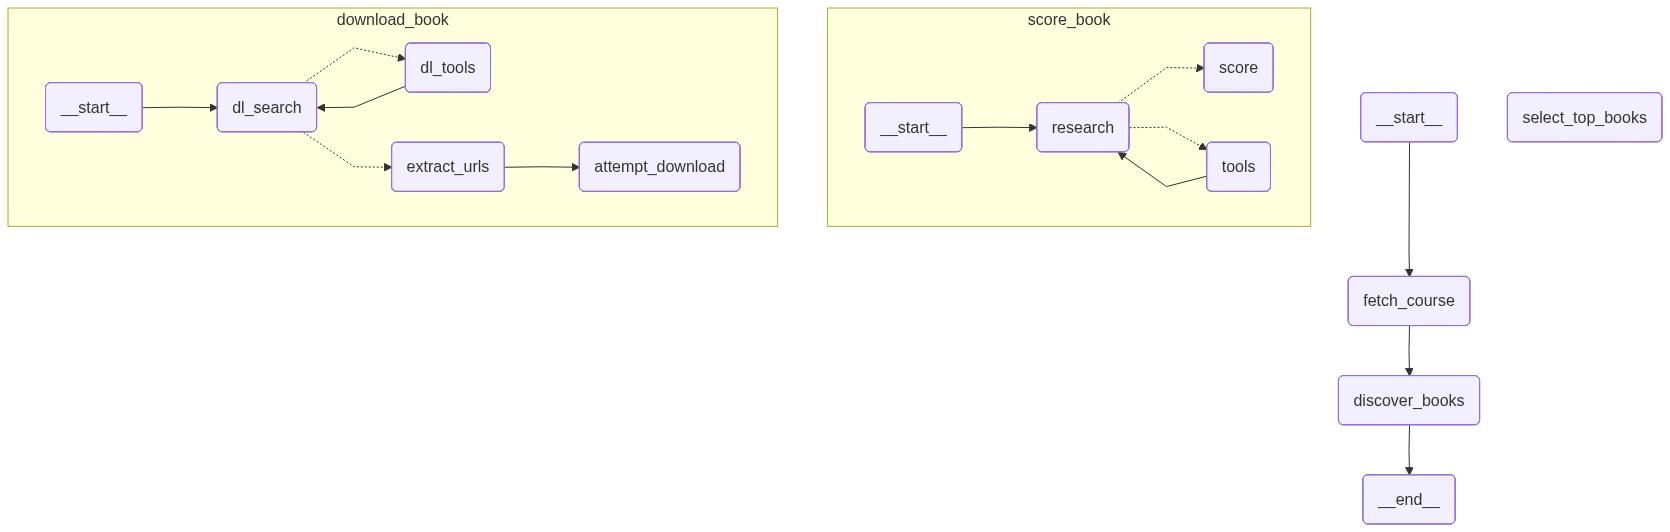


Discovery Sub-Graph:


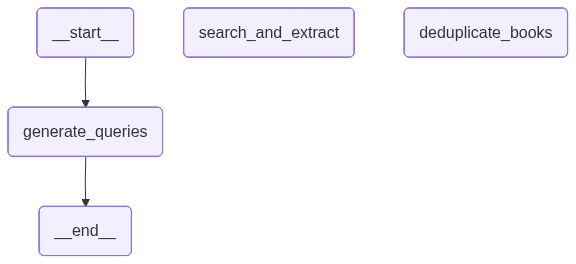


Scoring Sub-Graph:


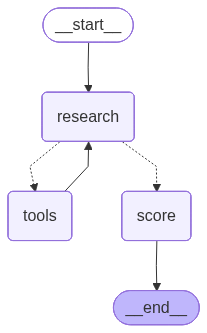


Download Sub-Graph:


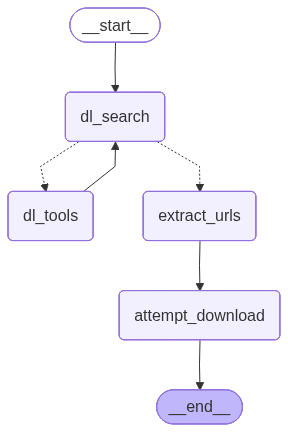

In [8]:
# Display the workflow graphs
from IPython.display import Image, display

print("Main Workflow (xray=True):")
display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))

print("\nDiscovery Sub-Graph:")
display(Image(discovery_graph.get_graph().draw_mermaid_png()))

print("\nScoring Sub-Graph:")
display(Image(scoring_graph.get_graph().draw_mermaid_png()))

print("\nDownload Sub-Graph:")
display(Image(download_graph.get_graph().draw_mermaid_png()))

In [9]:
# ═══════════════════════════════════════════════════════════════
# Execute the Workflow
# ═══════════════════════════════════════════════════════════════


async def run_workflow(course_level: str = DEFAULT_COURSE_LEVEL):
    """Run the full book-selection + download pipeline.

    Args:
        course_level: Academic level of the course — "bachelor", "master", or "phd".
                      Affects C_scope scoring (book level vs. course level).
    """
    print(f"🚀 Starting workflow (course_level={course_level})…")
    result = await workflow.ainvoke({"course_level": course_level})
    print("\n✅ Workflow complete")
    print(f"   📚 Discovered: {len(result.get('discovered_books', []))} books")
    print(f"   📊 Scored:     {len(result.get('scored_books', []))} books")
    print(f"   ⬇️  Downloads:  {len(result.get('download_results', []))} attempts")

    # Print scored books summary
    for s in result.get("scored_books", []):
        title = s.get("book_title", "?")[:55]
        sf = s.get("S_final", 0)
        err = s.get("error")
        if err:
            print(f"   ❌ {title}: {err}")
        else:
            print(f"   ✅ {title}: S_final={sf:.3f}")

    # Print download results
    for dr in result.get("download_results", []):
        title = dr.get("book_title", "?")[:55]
        status = dr.get("status", "?")
        if status == "success":
            print(f"   💾 Downloaded: {title} → {dr.get('file_path', '?')}")
        else:
            print(f"   ⚠️  {status}: {title}")

    return result


result = await run_workflow(course_level="bachelor")

🚀 Starting workflow (course_level=bachelor)…
  🎓 Course level: bachelor

🧠 Generated 12 queries:
    1. Big Data textbook 2026
    2. Big Data textbook
    3. data science textbook 2026
    4. NoSQL distributed systems textbook
    5. Big Data syllabus reading list
    6. best Big Data textbooks
    7. Hadoop Spark NoSQL textbook
    8. Big Data processing textbook
    9. Kai Hwang Big Data textbook
   10. Alexandre de Lima Bizerra Big Data
   11. Big Data architecture textbook
   12. data mining machine learning textbook

   Rationale: Identified the subject as 'Big Data' or 'Data Science' due to the course's comprehensive coverage of storage (NoSQL, HDFS), processing (MapReduce, Spark), and analysis (ML, data mining). The queries p

🗺️  Fanning out 12 queries to parallel search_and_extract workers…
   📗 "NoSQL distributed systems textbook" → 4 book(s): Advanced Data Management: For , SQL & NoSQL Databases: Models,, Joe Celko's Complete Guide to 
   📗 "Hadoop Spark NoSQL textbook" → 5

/Users/khajievroma/Projects/lab_tutor/backend/app/modules/curricularalignmentarchitect/tools.py:456: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/khajievroma/Projects/lab_tutor/backend/app/modules/curricularalignmentarchitect/tools.py:456: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/khajievroma/Projects/lab_tutor/backend/app/modules/curricularalignmentarchitect/tools.py:456: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/khajievroma/Projects/lab_tutor/backend/app/modules/curricularalignmentarchitect/tools.py:456: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/khajievroma/Projects/lab_tutor/backend/app/modules/cu


  📋 Found 0 candidate URLs for "Essentials of Big Data Analytics: Applications in ":
  ❌ No candidate URLs for "Essentials of Big Data Analytics: Applications in "

  📋 Found 3 candidate URLs for "Big Data: Concepts, Technology, and Architecture":
      1. [0.8] https://onlinelibrary.wiley.com/doi/book/10.1002/9781119701859
      2. [0.5] https://www.researchgate.net/publication/350204270_Big_Data_Concepts_Technology_
      3. [0.2] https://openlibrary.org/works/OL21677847W
  ⬇️  Attempt 1/2: [0.8] → https://onlinelibrary.wiley.com/doi/book/10.1002/9781119701859...
      ⚠️  Failed: HTTP Error 403: Forbidden
  ⬇️  Attempt 2/2: [0.5] → https://www.researchgate.net/publication/350204270_Big_Data_Concepts_T...

  📋 Found 3 candidate URLs for "A Hands-on Introduction to Big Data Analytics":
      1. [1.0] https://sk.sagepub.com/book/mono/download/a-hands-on-introduction-to-big-data-an
      2. [0.8] https://www.perlego.com/book/5056202/a-handson-introduction-to-big-data-analytic
      3. 

In [10]:
API_KEY

'sk-iI9OTzVrqnbGNmCMa2HS1vpX7gtZkJOfQ794AC2nxCRnpBd9'

In [11]:
# ═══════════════════════════════════════════════════════════════
# Ranked Results
# ═══════════════════════════════════════════════════════════════

ranked = sorted(
    result["scored_books"],
    key=lambda x: x.get("S_final", 0),
    reverse=True,
)

# ── Leaderboard ─────────────────────────────────────────────────
print("=" * 115)
print(
    f"{'#':<4} {'S_final':>7} {'S+prac':>7} │ "
    f"{'C_top':>5} {'C_str':>5} {'C_sco':>5} "
    f"{'C_pub':>5} {'C_aut':>5} {'C_tim':>5} {'C_pra':>5} │ TITLE"
)
print("─" * 115)

for i, r in enumerate(ranked, 1):
    print(
        f"{i:<4} "
        f"{r.get('S_final', 0):>7.3f} "
        f"{r.get('S_final_with_prac', 0):>7.3f} │ "
        f"{r.get('C_topic', 0):>5.2f} "
        f"{r.get('C_struc', 0):>5.2f} "
        f"{r.get('C_scope', 0):>5.2f} "
        f"{r.get('C_pub', 0):>5.2f} "
        f"{r.get('C_auth', 0):>5.2f} "
        f"{r.get('C_time', 0):>5.2f} "
        f"{r.get('C_prac', 0):>5.2f} │ "
        f"{r.get('book_title', '?')[:55]}"
    )

print("─" * 115)
print(
    "\nS_final = 0.30·C_topic + 0.20·C_struc + 0.15·C_scope "
    "+ 0.15·C_pub + 0.10·C_auth + 0.10·C_time"
)
if W_PRAC > 0:
    print(f"S+prac  = {1 - W_PRAC:.2f}·S_final + {W_PRAC:.2f}·C_prac")
else:
    print(f"S+prac  = S_final  (W_PRAC={W_PRAC}, practicality disabled)")

# ── Top 3 Detail ────────────────────────────────────────────────
CRITERIA = [
    ("C_topic", "Topic Coverage", 0.30),
    ("C_struc", "Structure", 0.20),
    ("C_scope", "Scope & Depth", 0.15),
    ("C_pub", "Publisher", 0.15),
    ("C_auth", "Author", 0.10),
    ("C_time", "Recency", 0.10),
    ("C_prac", "Practicality", W_PRAC if W_PRAC > 0 else 0.0),
]

print("\n" + "=" * 115)
print("🏆 TOP 3 — DETAILED RATIONALE\n")

for i, r in enumerate(ranked[:3], 1):
    print(f"{'━' * 80}")
    print(f"  #{i}  {r.get('book_title', '?')}")
    print(f"       by {r.get('book_authors', '?')}")
    print(
        f"       S_final = {r.get('S_final', 0):.4f}  │  "
        f"S+prac = {r.get('S_final_with_prac', 0):.4f}"
    )
    for key, label, w in CRITERIA:
        sc = r.get(key, 0)
        rat = r.get(f"{key}_rationale", "")
        print(f"    {label:<16} {sc:.2f} × {w:.2f} = {sc * w:.3f}  │ {rat[:70]}")
    print()

#    S_final  S+prac │ C_top C_str C_sco C_pub C_aut C_tim C_pra │ TITLE
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1      0.730   0.730 │  0.70  0.40  1.00  0.80  0.70  1.00  0.70 │ Big Data: Concepts, Technology, and Architecture
2      0.700   0.700 │  0.70  0.40  1.00  0.80  0.40  1.00  0.70 │ Essentials of Big Data Analytics: Applications in R and
3      0.650   0.650 │  0.40  0.40  1.00  1.00  0.70  0.80  0.70 │ SQL & NoSQL Databases: Models, Languages, Consistency O
4      0.610   0.610 │  0.40  0.40  1.00  0.80  0.40  1.00  1.00 │ A Hands-on Introduction to Big Data Analytics
5      0.590   0.590 │  0.70  0.40  0.70  0.50  0.40  0.80  1.00 │ Practical Big Data Analytics: Hands-on techniques to im
6      0.560   0.560 │  0.70  0.40  0.70  0.50  0.40  0.50  1.00 │ Big Data Architect’s Handbook: A guide to building prof
7      0.550   0.550 │  0.40  0.10  0.40  1.00  1.00  1.00  0.70 │ Principles of Distribut

In [13]:
result["download_results"]

[{'book_title': 'Big Data: Concepts, Technology, and Architecture',
  'status': 'failed',
  'error': 'Tried 2 URL(s), all failed. See manual_urls for manual download.',
  'tried_urls': ['https://onlinelibrary.wiley.com/doi/book/10.1002/9781119701859',
   'https://www.researchgate.net/publication/350204270_Big_Data_Concepts_Technology_and_Architecture'],
  'manual_urls': ['https://openlibrary.org/works/OL21677847W']},
 {'book_title': 'Essentials of Big Data Analytics: Applications in R and Python',
  'status': 'no_urls',
  'error': 'No candidate download URLs found.'},
 {'book_title': 'SQL & NoSQL Databases: Models, Languages, Consistency Options and Architectures for Big Data Management',
  'book_authors': 'Andreas Meier, Michael Kaufmann',
  'status': 'success',
  'file_path': '/Users/khajievroma/Projects/lab_tutor/backend/data/books/SQL_NoSQL_Databases_Models_Languages_Consistency_Options_and_Architectures_for_B_1.pdf',
  'file_info': 'Saved to: /Users/khajievroma/Projects/lab_tutor/